fixed  QuickCW      95% UL Mc = 6.113e+09 Msun (+/- 5.6e+07; log10 = 9.786; tau = 11530, N_eff = 7782)
fixed  Enterprise   95% UL Mc = 6.044e+09 Msun (+/- 2.3e+08; log10 = 9.781; tau = 190, N_eff = 378)
fixed  QuickCW-dL   95% UL Mc = 5.920e+09 Msun (+/- 2.5e+07; log10 = 9.772; tau = 2660, N_eff = 37589)
broad  QuickCW      95% UL Mc = 5.801e+09 Msun (+/- 4.1e+07; log10 = 9.764; tau = 17724, N_eff = 5642)
broad  Enterprise   95% UL Mc = 6.292e+09 Msun (+/- 2.0e+08; log10 = 9.799; tau = 1078, N_eff = 67)
broad  QuickCW-dL   95% UL Mc = 5.928e+09 Msun (+/- 1.9e+07; log10 = 9.773; tau = 5589, N_eff = 17894)


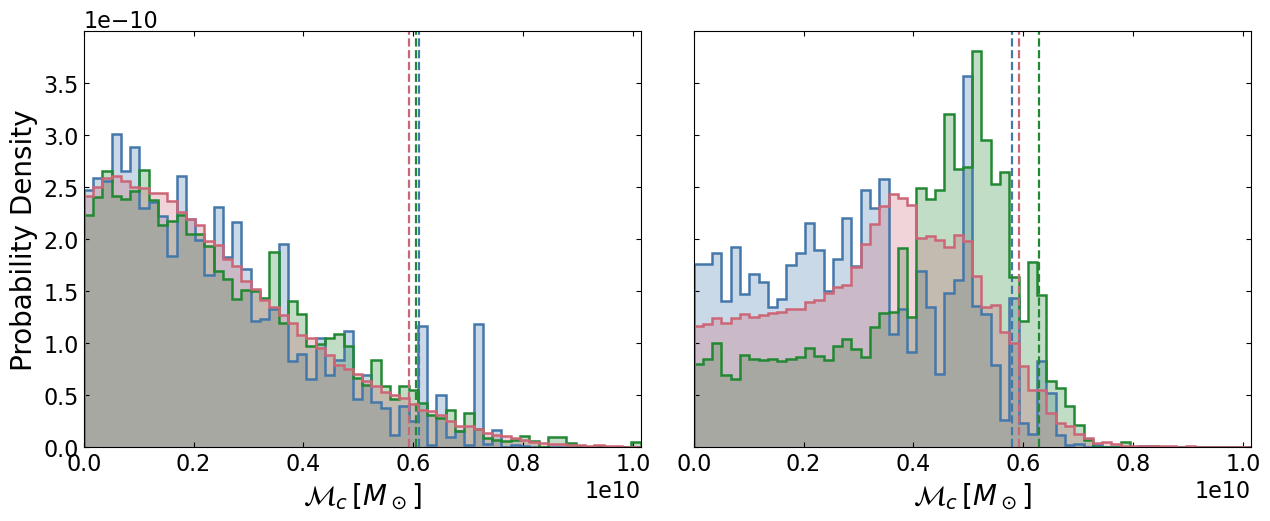

In [2]:
# %% [markdown]
# Frequency-marginalized 95% Mc upper limit, fixed (left) and broad (right) fGW.
# Three pipelines per panel, plotted UNIFORM in Mc (linear axis) as shaded step histograms
# on a shared bin grid starting at zero; dashed lines are the 95% ULs.
# Colors match Figure 3: QuickCW #4477AA, Enterprise #228833, QuickCW-dL #CC6677.
# UL uncertainties use N_eff = min(N_masked, N_raw/tau): the raw chain's ESS caps the
# information content, and masked samples are widely spaced in chain time.
# %%
%matplotlib inline
import numpy as np
import h5py
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import emcee

np.random.seed(42)
TARGET_DL = 75.4; TOL = 0.01; CONF = 0.95; ENT_BURN = 3000
mpc = 3.086e22; c = 299792458.0; T_sun = 1.327124400e20 / c**3
QCW_C, ENT_C, DL_C = '#4477AA', '#228833', '#CC6677'
THIN_TAU = 10
# %%
H = '/scratch/na00078/projects/IPTA_MDC2/h5_files/'
fixed_series = [
    ('QuickCW',    H + 'G2D1_narrow_UL_fixed_gamma_17_dec_2025_outfile.h5', 'qcw',  QCW_C),
    ('Enterprise', H + 'core_single_MDC2_DS1_new.h5',                       'ent',  ENT_C),
    ('QuickCW-dL', H + 'G2D1_fixed_UL_loki_100M_lastTOA_10_Jul_2026.h5',    'loki', DL_C),
]
broad_series = [
    ('QuickCW',    H + 'G2D1_broad_UL_1e9_fixed_gamma_outfile.h5',          'qcw',  QCW_C),
    ('Enterprise', H + 'core_single_MDC2_DS1_varyfgw.h5',                   'ent',  ENT_C),
    ('QuickCW-dL', H + 'G2D1_broad_UL_loki_100M_lastTOA_10_Jul_2026.h5',    'loki', DL_C),
]

def col(f, name):
    pn = [x.decode() for x in f['par_names'][:]]
    return f['samples_cold'][0, :, pn.index(name)]

def tau_of(x):
    xt = x[::THIN_TAU] if len(x) > 5_000_000 else x
    try:
        t = float(emcee.autocorr.integrated_time(xt, quiet=True)[0])
        return t * (THIN_TAU if len(x) > 5_000_000 else 1)
    except Exception:
        return 1.0

def mc_posterior(path, kind):
    with h5py.File(path, 'r') as f:
        if 'samples_cold' in f:
            fgw = col(f, '0_log10_fgw')
            mc  = col(f, '0_log10_mc')
            if kind == 'qcw':
                h  = 10 ** col(f, '0_log10_h')
                dL = 2 * (10**mc * T_sun)**(5/3) * (np.pi * 10**fgw)**(2/3) / h * c / mpc
            else:
                dL = 10 ** col(f, '0_log10_dist')
        else:
            ch = f['chain'][...][ENT_BURN:]
            pn = [x.decode() for x in f['params'][:]]
            mc = ch[:, pn.index('log10_mc')]
            dL = np.full(len(mc), TARGET_DL)
    tau = tau_of(mc)
    ess_raw = len(mc) / tau                # ESS of the sequential chain
    m = (dL >= TARGET_DL * (1 - TOL)) & (dL <= TARGET_DL * (1 + TOL))
    n_eff = min(m.sum(), ess_raw)          # masked samples are widely spaced
    return 10 ** mc[m], n_eff, tau

def ul95(mc, n_eff):
    u = np.quantile(mc, CONF)
    sub = mc if len(mc) <= 200_000 else np.random.choice(mc, 200_000, replace=False)
    fq = gaussian_kde(sub).evaluate([u])[0]
    return u, np.sqrt(CONF * (1 - CONF)) / (fq * np.sqrt(n_eff))
# %%
results = {'fixed': {}, 'broad': {}}
for panel, cfg in [('fixed', fixed_series), ('broad', broad_series)]:
    for name, path, kind, colr in cfg:
        mc, n_eff, tau = mc_posterior(path, kind)
        u, uerr = ul95(mc, n_eff)
        results[panel][name] = (mc, u, colr)
        print(f'{panel:6s} {name:12s} 95% UL Mc = {u:.3e} Msun (+/- {uerr:.1e}; '
              f'log10 = {np.log10(u):.3f}; tau = {tau:.0f}, N_eff = {n_eff:.0f})')
allmc = np.concatenate([v[0] for pan in results.values() for v in pan.values()])
bins = np.linspace(0.0, allmc.max(), 61)
# %%
plt.rcParams.update({'font.size': 16})
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharex=True, sharey=True)
for ax, panel in [(axes[0], 'fixed'), (axes[1], 'broad')]:
    for name, (mc, u, colr) in results[panel].items():
        ax.hist(mc, bins=bins, density=True, histtype='stepfilled', color=colr, alpha=0.28, lw=0)
        ax.hist(mc, bins=bins, density=True, histtype='step', color=colr, lw=1.8)
        ax.axvline(u, color=colr, lw=1.6, ls='--')
    ax.set_xlim(0.0, bins[-1])             # kill the default margin: axis starts at 0
    ax.tick_params(direction='in', top=True, right=True, which='both')
    ax.set_xlabel(r'$\mathcal{M}_c\,[M_\odot]$', fontsize=20)
axes[0].set_ylabel('Probability Density', fontsize=20)
plt.tight_layout()
fig.savefig('G2D1_freq_marginalized_UL_fixed_broad.pdf', bbox_inches='tight')
plt.show()

fixed  QuickCW      Mc: log10=9.786 +/- 0.0040   h0: log10=-13.415 +/- 0.0052   tau=11530 N_eff=7782
fixed  Enterprise   Mc: log10=9.781 +/- 0.0162   h0: log10=-13.422 +/- 0.0256   tau=190 N_eff=378
fixed  QuickCW-dL   Mc: log10=9.772 +/- 0.0019   h0: log10=-13.437 +/- 0.0031   tau=2660 N_eff=37589
broad  QuickCW      Mc: log10=9.764 +/- 0.0030   h0: log10=-12.805 +/- 0.0117   tau=17724 N_eff=5642
broad  Enterprise   Mc: log10=9.799 +/- 0.0135   h0: log10=-12.553 +/- 0.0261   tau=1078 N_eff=67
broad  QuickCW-dL   Mc: log10=9.773 +/- 0.0014   h0: log10=-12.689 +/- 0.0066   tau=5589 N_eff=17894
saved G2D1_broad_freq_marginalized_UL
saved G2D1_fixed_freq_marginalized_UL


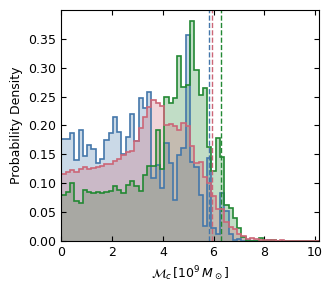

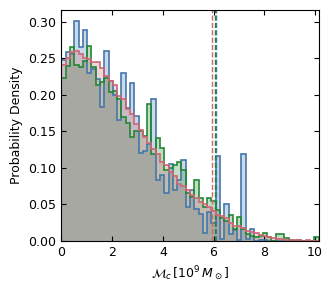

In [3]:
# ===== FINAL: frequency-marginalized 95% Mc UL, two separate Overleaf-ready figures =====
# Also prints final table numbers: Mc and h0 95% ULs with N_eff corrected errors.
import numpy as np
import h5py
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import emcee

np.random.seed(42)
TARGET_DL = 75.4; TOL = 0.01; CONF = 0.95; ENT_BURN = 3000; THIN_TAU = 10
mpc = 3.086e22; c = 299792458.0; T_sun = 1.327124400e20 / c**3
F_FIX = np.log10(3.7e-9)
COLS = {'QuickCW': '#4477AA', 'Enterprise': '#228833', 'QuickCW-dL': '#CC6677'}
H = '/scratch/na00078/projects/IPTA_MDC2/h5_files/'
SERIES = {
 'fixed': [('QuickCW', H+'G2D1_narrow_UL_fixed_gamma_17_dec_2025_outfile.h5', 'qcw'),
           ('Enterprise', H+'core_single_MDC2_DS1_new.h5', 'ent'),
           ('QuickCW-dL', H+'G2D1_fixed_UL_loki_100M_lastTOA_10_Jul_2026.h5', 'loki')],
 'broad': [('QuickCW', H+'G2D1_broad_UL_1e9_fixed_gamma_outfile.h5', 'qcw'),
           ('Enterprise', H+'core_single_MDC2_DS1_varyfgw.h5', 'ent'),
           ('QuickCW-dL', H+'G2D1_broad_UL_loki_100M_lastTOA_10_Jul_2026.h5', 'loki')]}

def getcol(f, name):
    pn = [x.decode() for x in f['par_names'][:]]
    return f['samples_cold'][0, :, pn.index(name)]

def tau_of(x):
    xt = x[::THIN_TAU] if len(x) > 5_000_000 else x
    try:
        t = float(emcee.autocorr.integrated_time(xt, quiet=True)[0])
        return t * (THIN_TAU if len(x) > 5_000_000 else 1)
    except Exception:
        return 1.0

def derive_lh(mc, fgw, dl_mpc):
    return (np.log10(2) + (5/3)*(mc + np.log10(T_sun)) + (2/3)*(np.log10(np.pi) + fgw)
            - (np.log10(dl_mpc) + np.log10(mpc) - np.log10(c)))

def load(path, kind):
    with h5py.File(path, 'r') as f:
        if 'samples_cold' in f:
            fgw = getcol(f, '0_log10_fgw'); mc = getcol(f, '0_log10_mc')
            if kind == 'qcw':
                lh = getcol(f, '0_log10_h')
                dL = 2*(10**mc*T_sun)**(5/3)*(np.pi*10**fgw)**(2/3)/10**lh*c/mpc
            else:
                dLl = getcol(f, '0_log10_dist'); dL = 10**dLl
                lh = derive_lh(mc, fgw, dL)
        else:
            ch = f['chain'][...][ENT_BURN:]
            pn = [x.decode() for x in f['params'][:]]
            mc = ch[:, pn.index('log10_mc')]
            fgw = ch[:, pn.index('log10_fgw')] if 'log10_fgw' in pn else np.full(len(mc), F_FIX)
            dL = np.full(len(mc), TARGET_DL)
            lh = derive_lh(mc, fgw, TARGET_DL)
    tau = tau_of(mc); ess = len(mc)/tau
    m = (dL >= TARGET_DL*(1-TOL)) & (dL <= TARGET_DL*(1+TOL))
    n_eff = min(m.sum(), ess)
    return 10**mc[m], 10**lh[m], n_eff, tau

def ul(x, n_eff):
    u = np.quantile(x, CONF)
    sub = x if len(x) <= 200_000 else np.random.choice(x, 200_000, replace=False)
    fq = gaussian_kde(sub).evaluate([u])[0]
    return u, np.sqrt(CONF*(1-CONF))/(fq*np.sqrt(max(n_eff, 1.0)))

res = {}
for panel, cfg in SERIES.items():
    res[panel] = {}
    for name, path, kind in cfg:
        mc, h0, n_eff, tau = load(path, kind)
        umc, emc = ul(mc, n_eff); uh, eh = ul(h0, n_eff)
        res[panel][name] = (mc, umc)
        print(f"{panel:6s} {name:12s} Mc: log10={np.log10(umc):.3f} +/- {emc/(umc*np.log(10)):.4f}"
              f"   h0: log10={np.log10(uh):.3f} +/- {eh/(uh*np.log(10)):.4f}   tau={tau:.0f} N_eff={n_eff:.0f}")

allmax = max(v[0].max() for pan in res.values() for v in pan.values())/1e9
bins = np.linspace(0.0, allmax, 61)
plt.rcParams.update({'font.size': 9})
for panel, fname in [('broad', 'G2D1_broad_freq_marginalized_UL'), ('fixed', 'G2D1_fixed_freq_marginalized_UL')]:
    fig, ax = plt.subplots(figsize=(3.4, 3.0))
    for name, (mc, u) in res[panel].items():
        cc = COLS[name]
        ax.hist(mc/1e9, bins=bins, density=True, histtype='stepfilled', color=cc, alpha=0.28, lw=0)
        ax.hist(mc/1e9, bins=bins, density=True, histtype='step', color=cc, lw=1.2)
        ax.axvline(u/1e9, color=cc, lw=1.0, ls='--')
    ax.set_xlim(0.0, bins[-1])
    ax.tick_params(direction='in', top=True, right=True, which='both')
    ax.set_xlabel(r'$\mathcal{M}_c\,[10^{9}\,M_\odot]$')
    ax.set_ylabel('Probability Density')
    plt.tight_layout()
    fig.savefig(fname + '.pdf', bbox_inches='tight')
    fig.savefig(fname + '.png', dpi=300, bbox_inches='tight')
    print('saved', fname)
